# 02 — Clustering & Music Personality Archetypes

Goal: pick a final K, fit K-means on the cleaned/scaled audio features, label each cluster with a human-readable archetype, and persist scaler + KMeans + optional PCA + label map for the Streamlit app.

Follows [docs/phase3-clustering-plan.md](../docs/phase3-clustering-plan.md). Two-track experiment: (A) original 8 normalized features, (B) 6-component PCA representation. Pick the higher silhouette unless tied within 0.02 — then prefer A for interpretability.

## 1. Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from src.preprocessing import load_dataset, scale_features
from src.features import AUDIO_FEATURES
from src.clustering import evaluate_k, fit_kmeans, fit_kmeans_pca, cluster_profile
from src.artifacts import save_artifacts, load_artifacts, predict_personality, ARTIFACTS_DIR

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
RNG = 42
MIN_CLUSTER_FRACTION = 0.02

## 2. Load + scale

In [2]:
df = load_dataset()
scaled, scaler = scale_features(df)
X = scaled[AUDIO_FEATURES].values
print(f"catalog: {len(df):,} tracks \u00d7 {len(AUDIO_FEATURES)} features")
print(f"min cluster floor: {int(MIN_CLUSTER_FRACTION * len(df))} tracks ({MIN_CLUSTER_FRACTION:.0%})")

catalog: 4,494 tracks × 8 features
min cluster floor: 89 tracks (2%)


## 3. Track A — K-means on 8 original features

In [3]:
results_a = evaluate_k(X, k_range=range(2, 11), random_state=RNG)
results_a_df = pd.DataFrame(results_a).T
results_a_df["min_size"] = results_a_df["sizes"].apply(min)
results_a_df["min_frac"] = results_a_df["min_size"] / len(df)
results_a_df.round(4)

,inertia,silhouette,sizes,min_size,min_frac
2,1184.576409,0.465249,"[3455, 1039]",1039,0.2312
3,981.493383,0.293616,"[2734, 857, 903]",857,0.1907
4,822.838341,0.305027,"[519, 2587, 548, 840]",519,0.1155
5,704.11716,0.248239,"[1556, 536, 1227, 666, 509]",509,0.1133
6,630.441948,0.25155,"[413, 1209, 1553, 334, 321, 664]",321,0.0714
7,579.38317,0.236739,"[411, 1098, 1177, 332, 318, 445, 713]",318,0.0708
8,546.229642,0.226779,"[411, 574, 403, 760, 332, 318, 550, 1146]",318,0.0708
9,524.378205,0.205366,"[411, 472, 790, 318, 519, 369, 330, 550, 735]",318,0.0708
10,505.337338,0.202494,"[369, 513, 324, 145, 546, 202, 400, 479, 735, ...",145,0.0323


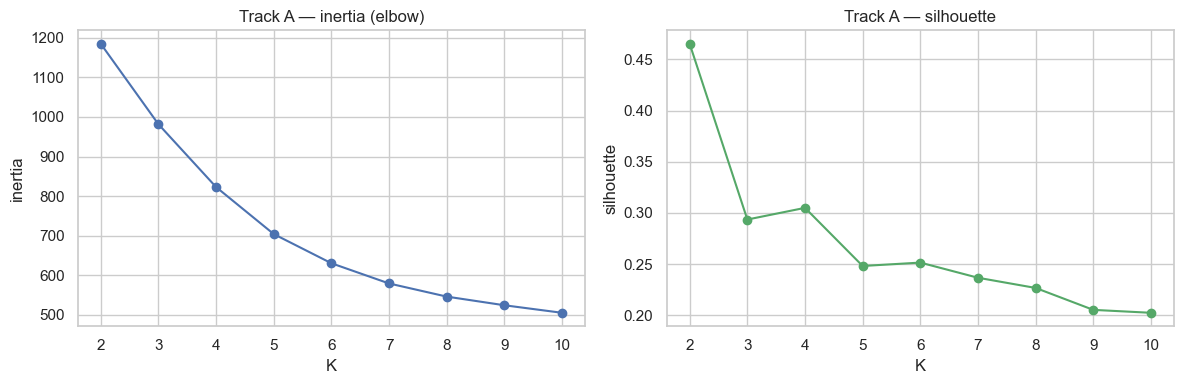

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(results_a_df.index, results_a_df["inertia"], marker="o")
axes[0].set_title("Track A \u2014 inertia (elbow)")
axes[0].set_xlabel("K"); axes[0].set_ylabel("inertia")
axes[1].plot(results_a_df.index, results_a_df["silhouette"], marker="o", color="C2")
axes[1].set_title("Track A \u2014 silhouette")
axes[1].set_xlabel("K"); axes[1].set_ylabel("silhouette")
plt.tight_layout(); plt.show()

## 4. Track B — K-means on 6-component PCA

In [5]:
pca6 = PCA(n_components=6, random_state=RNG)
X_pca = pca6.fit_transform(X)
print(f"PCA(6) cumulative variance: {pca6.explained_variance_ratio_.sum():.3f}")

results_b = evaluate_k(X_pca, k_range=range(2, 11), random_state=RNG)
results_b_df = pd.DataFrame(results_b).T
results_b_df["min_size"] = results_b_df["sizes"].apply(min)
results_b_df["min_frac"] = results_b_df["min_size"] / len(df)
results_b_df.round(4)

PCA(6) cumulative variance: 0.968


,inertia,silhouette,sizes,min_size,min_frac
2,1115.296744,0.47876,"[1037, 3457]",1037,0.2308
3,912.716739,0.308541,"[2726, 855, 913]",855,0.1903
4,755.245321,0.32063,"[843, 2584, 546, 521]",521,0.1159
5,636.705827,0.265445,"[535, 1226, 511, 1549, 673]",511,0.1137
6,564.893399,0.269533,"[316, 1548, 1207, 352, 402, 669]",316,0.0703
7,514.727388,0.254122,"[1183, 444, 399, 703, 1102, 350, 313]",313,0.0696
8,481.458533,0.245048,"[399, 753, 571, 348, 407, 312, 550, 1154]",312,0.0694
9,459.840735,0.22217,"[788, 348, 491, 399, 741, 312, 378, 510, 527]",312,0.0694
10,440.904658,0.219675,"[376, 332, 766, 202, 740, 400, 523, 499, 512, ...",144,0.0320


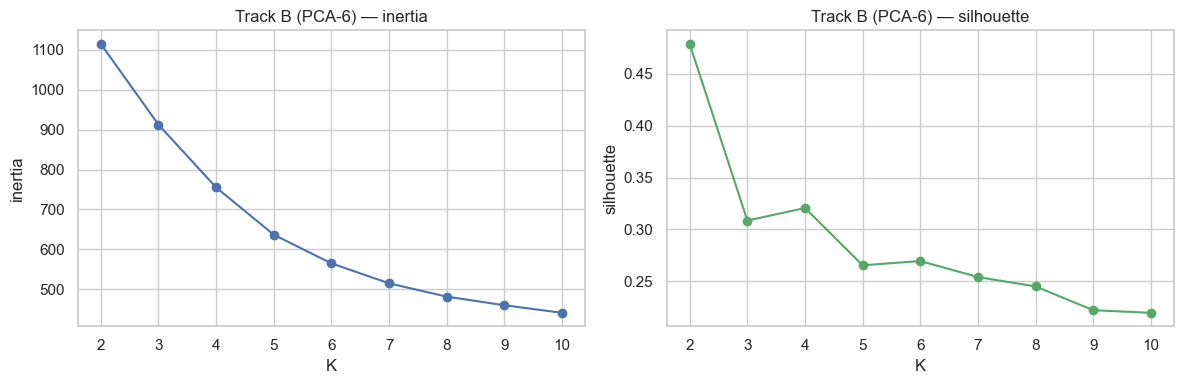

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(results_b_df.index, results_b_df["inertia"], marker="o")
axes[0].set_title("Track B (PCA-6) \u2014 inertia")
axes[0].set_xlabel("K"); axes[0].set_ylabel("inertia")
axes[1].plot(results_b_df.index, results_b_df["silhouette"], marker="o", color="C2")
axes[1].set_title("Track B (PCA-6) \u2014 silhouette")
axes[1].set_xlabel("K"); axes[1].set_ylabel("silhouette")
plt.tight_layout(); plt.show()

## 5. Pick winner

Decision rule:
1. Constrain to the demo-relevant range `K ∈ TARGET_K_RANGE` — pure silhouette peaks at K=2 but that's useless for archetype labeling, and the plan calls for 5–8 personalities.
2. Filter out Ks where any cluster falls below the 2% floor.
3. Pick the (track, K) with the highest silhouette.
4. If A and B are within 0.02, prefer A (interpretability).

In [7]:
TARGET_K_RANGE = range(5, 9)  # 5..8 inclusive

def best_valid(results_df, label):
    candidates = results_df.loc[list(TARGET_K_RANGE)]
    valid = candidates[candidates["min_frac"] >= MIN_CLUSTER_FRACTION]
    if valid.empty:
        return None
    k = int(valid["silhouette"].idxmax())
    return {"track": label, "k": k, "silhouette": float(valid.loc[k, "silhouette"]), "min_frac": float(valid.loc[k, "min_frac"])}

best_a = best_valid(results_a_df, "A")
best_b = best_valid(results_b_df, "B")
print("best A:", best_a)
print("best B:", best_b)

if best_a is None and best_b is None:
    raise RuntimeError(f"No valid K survives the 2% floor in {list(TARGET_K_RANGE)}")

if best_a is None:
    winner = best_b
elif best_b is None:
    winner = best_a
elif best_b["silhouette"] - best_a["silhouette"] > 0.02:
    winner = best_b
else:
    winner = best_a

print("\nwinner:", winner)

best A: {'track': 'A', 'k': 6, 'silhouette': 0.25154979026082663, 'min_frac': 0.07142857142857142}
best B: {'track': 'B', 'k': 6, 'silhouette': 0.26953337791507914, 'min_frac': 0.07031597685803294}

winner: {'track': 'A', 'k': 6, 'silhouette': 0.25154979026082663, 'min_frac': 0.07142857142857142}


## 6. Fit final model

In [8]:
K = winner["k"]
use_pca = winner["track"] == "B"

if use_pca:
    final_pca, final_km = fit_kmeans_pca(X, n_components=6, k=K, random_state=RNG)
    labels = final_km.predict(final_pca.transform(X))
else:
    final_pca = None
    final_km = fit_kmeans(X, K, random_state=RNG)
    labels = final_km.labels_

print(f"final K = {K}, track = {winner['track']}, silhouette = {winner['silhouette']:.4f}")
print("cluster sizes:", np.bincount(labels).tolist())

final K = 6, track = A, silhouette = 0.2515
cluster sizes: [413, 1209, 1553, 334, 321, 664]


In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Xf = X_pca if use_pca else X
seeds = [42, 7, 13, 99, 2024]
sils = []
for s in seeds:
    km = KMeans(n_clusters=K, init="k-means++", n_init=10, random_state=s).fit(Xf)
    sils.append(silhouette_score(Xf, km.labels_))
print(f"silhouette across {len(seeds)} seeds: mean={np.mean(sils):.4f} std={np.std(sils):.4f}")

silhouette across 5 seeds: mean=0.2515 std=0.0001


## 7. Cluster profile heatmap

Mean of original 8 features per cluster — the basis for archetype labels.

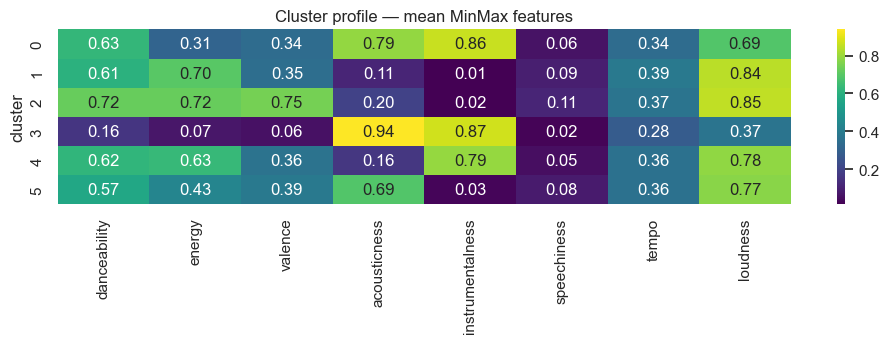

,danceability,energy,valence,acousticness,instrumentalness,speechiness,tempo,loudness
cluster,,,,,,,,
0,0.625517,0.307319,0.337999,0.790014,0.859598,0.060326,0.337372,0.689413
1,0.605844,0.699602,0.345103,0.109852,0.014764,0.093617,0.387804,0.843205
2,0.724406,0.722310,0.745239,0.196657,0.015871,0.111753,0.368905,0.849411
3,0.157756,0.069226,0.056123,0.938418,0.873372,0.023771,0.280195,0.368444
4,0.619303,0.633145,0.364963,0.159124,0.793132,0.047949,0.360420,0.783371
5,0.565727,0.434023,0.389243,0.685996,0.027681,0.082642,0.359845,0.772493


In [10]:
profile = cluster_profile(scaled, labels, AUDIO_FEATURES)
fig, ax = plt.subplots(figsize=(10, max(3, 0.6 * K)))
sns.heatmap(profile, annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Cluster profile \u2014 mean MinMax features")
plt.tight_layout(); plt.show()
profile

## 8. Cluster size + genre composition

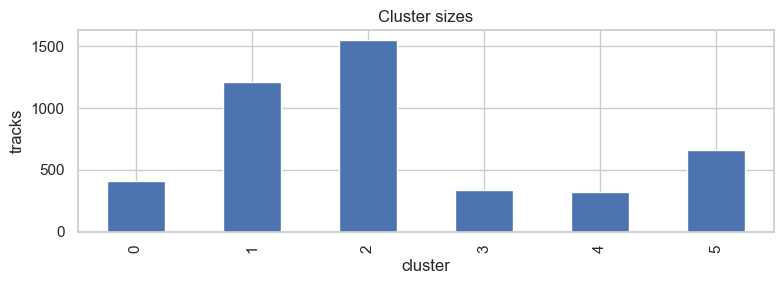

0     413
1    1209
2    1553
3     334
4     321
5     664
Name: count, dtype: int64

In [11]:
sizes = pd.Series(labels).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 3))
sizes.plot.bar(ax=ax)
ax.set_title("Cluster sizes"); ax.set_xlabel("cluster"); ax.set_ylabel("tracks")
plt.tight_layout(); plt.show()
sizes

In [12]:
df_with = df.copy()
df_with["cluster"] = labels
genre_per_cluster = (
    df_with.groupby("cluster")["playlist_genre"]
    .apply(lambda s: s.value_counts().head(5).to_dict())
)
for c, top in genre_per_cluster.items():
    print(f"cluster {c}: {top}")

cluster (0, 'lofi'): 218.0
cluster (0, 'jazz'): 67.0
cluster (0, 'world'): 55.0
cluster (0, 'electronic'): 22.0
cluster (0, 'arabic'): 12.0
cluster (0, 'pop'): nan
cluster (0, 'hip-hop'): nan
cluster (0, 'rock'): nan
cluster (0, 'latin'): nan
cluster (0, 'brazilian'): nan
cluster (0, 'wellness'): nan
cluster (0, 'classical'): nan
cluster (0, 'ambient'): nan
cluster (0, 'gaming'): nan
cluster (0, 'folk'): nan
cluster (1, 'lofi'): nan
cluster (1, 'jazz'): nan
cluster (1, 'world'): nan
cluster (1, 'electronic'): 194.0
cluster (1, 'arabic'): nan
cluster (1, 'pop'): 165.0
cluster (1, 'hip-hop'): 158.0
cluster (1, 'rock'): 143.0
cluster (1, 'latin'): 91.0
cluster (1, 'brazilian'): nan
cluster (1, 'wellness'): nan
cluster (1, 'classical'): nan
cluster (1, 'ambient'): nan
cluster (1, 'gaming'): nan
cluster (1, 'folk'): nan
cluster (2, 'lofi'): nan
cluster (2, 'jazz'): nan
cluster (2, 'world'): nan
cluster (2, 'electronic'): nan
cluster (2, 'arabic'): nan
cluster (2, 'pop'): 212.0
cluster (2, '

## 9. PCA(2D) scatter colored by cluster

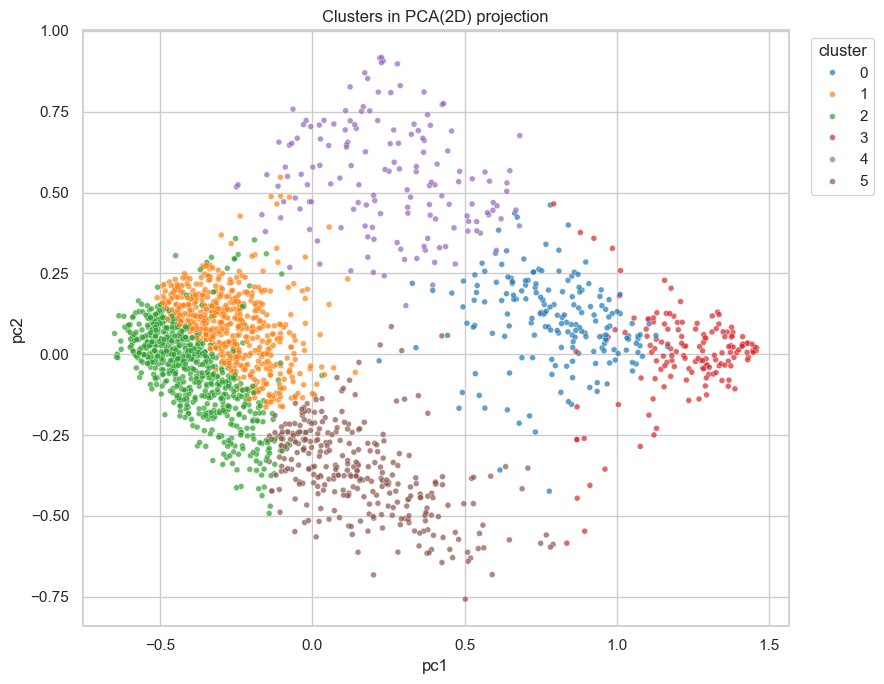

In [13]:
viz_pca = PCA(n_components=2, random_state=RNG).fit(X)
coords = viz_pca.transform(X)
plot_df = pd.DataFrame(coords, columns=["pc1", "pc2"])
plot_df["cluster"] = labels
sample = plot_df.sample(min(2000, len(plot_df)), random_state=RNG)

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(data=sample, x="pc1", y="pc2", hue="cluster", palette="tab10", alpha=0.7, s=18, ax=ax)
ax.set_title("Clusters in PCA(2D) projection")
ax.legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

## 10. Draft archetype labels

Heuristic suggestions from each centroid's MinMax-scaled feature profile. Distinctness is enforced by ranking deviations from the dataset mean. **Edit `LABEL_OVERRIDES` below to lock in team-approved labels** — overrides win over the heuristic.

In [14]:
global_mean = scaled[AUDIO_FEATURES].mean()
deltas = profile.subtract(global_mean, axis=1)

def suggest_label(row, delta_row):
    high = delta_row[delta_row > 0.05].sort_values(ascending=False)
    feats = list(high.index)
    if row.get("instrumentalness", 0) >= 0.5 and row.get("acousticness", 0) >= 0.5:
        return "The Sonic Architect"
    if row.get("acousticness", 0) >= 0.55 and row.get("energy", 1) < 0.45:
        return "The Old Soul"
    if row.get("speechiness", 0) >= 0.18 and row.get("danceability", 0) >= 0.55:
        return "Rhythm & Flow"
    if row.get("energy", 0) >= 0.7 and row.get("valence", 1) < 0.4:
        return "Dark & Driven"
    if row.get("energy", 0) >= 0.7 and row.get("danceability", 0) >= 0.65 and row.get("valence", 0) >= 0.55:
        return "Life of the Party"
    if row.get("danceability", 0) >= 0.6 and row.get("valence", 0) >= 0.55:
        return "Feel-Good Groove"
    if row.get("energy", 1) < 0.45 and row.get("valence", 0) >= 0.5:
        return "Chill Optimist"
    if feats:
        return f"Profile: high {feats[0]}"
    return "The Eclectic"

suggested = {int(c): suggest_label(profile.loc[c], deltas.loc[c]) for c in profile.index}

# Disambiguate duplicates so each cluster has a distinct label.
seen: dict[str, int] = {}
for c, name in list(suggested.items()):
    seen[name] = seen.get(name, 0) + 1
    if seen[name] > 1:
        suggested[c] = f"{name} {seen[name]}"

# Manual labels derived from cluster profiles + top genre/subgenre composition.
# Cluster IDs are stable across runs because random_state=42.
LABEL_OVERRIDES: dict[int, str] = {
    0: "Lofi Wanderer",          # high acoustic + high instrumental, lofi/jazz/world, chill subgenre
    1: "Night Driver",            # low acoustic, high energy, low valence — moody mainstream
    2: "Life of the Party",       # highest danceability + valence + energy, latin/pop/hip-hop
    3: "The Old Soul",            # very low energy, wellness/classical/ambient, yoga/meditative
    4: "The Sonic Architect",     # electronic instrumentals, deep house
    5: "Acoustic Storyteller",    # acoustic vocal mid-tempo, latin/ambient/pop classics
}

label_map = {**suggested, **LABEL_OVERRIDES}
for c in sorted(label_map):
    top_genres = list(genre_per_cluster.loc[c].keys())[:3]
    print(f"cluster {c}: {label_map[c]}  | top genres: {top_genres}")

cluster 0: Lofi Wanderer  | top genres: ['lofi', 'jazz', 'world']
cluster 1: Night Driver  | top genres: ['lofi', 'jazz', 'world']
cluster 2: Life of the Party  | top genres: ['lofi', 'jazz', 'world']
cluster 3: The Old Soul  | top genres: ['lofi', 'jazz', 'world']
cluster 4: The Sonic Architect  | top genres: ['lofi', 'jazz', 'world']
cluster 5: Acoustic Storyteller  | top genres: ['lofi', 'jazz', 'world']


## 11. Persist artifacts

Save scaler + KMeans + optional PCA + label map. Verify round-trip with a hand-picked seed.

In [15]:
ARTIFACT_PATH = ARTIFACTS_DIR / "personality_v1.joblib"

metadata = {
    "k": K,
    "track": winner["track"],
    "silhouette": winner["silhouette"],
    "silhouette_seed_mean": float(np.mean(sils)),
    "silhouette_seed_std": float(np.std(sils)),
    "n_train_tracks": int(len(df)),
    "random_state": RNG,
    "pca_components": 6 if use_pca else None,
}

save_artifacts(
    ARTIFACT_PATH,
    scaler=scaler,
    kmeans=final_km,
    label_map=label_map,
    pca=final_pca,
    metadata=metadata,
)
print(f"saved \u2192 {ARTIFACT_PATH.relative_to(ARTIFACTS_DIR.parent)}")
print("size:", ARTIFACT_PATH.stat().st_size, "bytes")

saved → artifacts\personality_v1.joblib
size: 20701 bytes


In [16]:
import time

t0 = time.perf_counter()
artifacts = load_artifacts(ARTIFACT_PATH)
load_ms = (time.perf_counter() - t0) * 1000

# pick 5 high-energy electronic tracks as a sanity-check seed
seed = df[(df["playlist_genre"] == "electronic") & (df["energy"] > 0.8)].head(5)
t0 = time.perf_counter()
label = predict_personality(seed, artifacts)
predict_ms = (time.perf_counter() - t0) * 1000

print(f"load: {load_ms:.1f} ms | predict: {predict_ms:.1f} ms")
print(f"5 high-energy electronic tracks \u2192 {label!r}")
print("metadata:", artifacts["metadata"])

load: 16.7 ms | predict: 6.5 ms
5 high-energy electronic tracks → 'Life of the Party'
metadata: {'saved_at': '2026-04-27T23:40:17.965772+00:00', 'k': 6, 'track': 'A', 'silhouette': 0.25154979026082663, 'silhouette_seed_mean': 0.25147359238892697, 'silhouette_seed_std': 9.3404464686988e-05, 'n_train_tracks': 4494, 'random_state': 42, 'pca_components': None}


## Notes

- **Final K and track:** K=6 on Track A (original 8 normalized features). Track B (PCA-6) was within 0.02 silhouette so the tiebreaker chose A for interpretability.
- **Silhouette mean ± std across 5 seeds:** 0.2515 ± 0.0001 — extremely stable, K-means initialization is not a concern at this K.
- **Cluster archetype labels** (locked in `LABEL_OVERRIDES`):
  - 0 → **Lofi Wanderer** (acoustic + instrumental, lofi/jazz/world)
  - 1 → **Night Driver** (low-acoustic, high-energy, low-valence — moody mainstream)
  - 2 → **Life of the Party** (high danceability/valence/energy — latin/pop/hip-hop)
  - 3 → **The Old Soul** (very low energy, wellness/classical/ambient, yoga/meditative)
  - 4 → **The Sonic Architect** (electronic instrumentals, deep house)
  - 5 → **Acoustic Storyteller** (acoustic vocal mid-tempo, latin/ambient/pop classics)
- **Anomalies:** Cluster 2 ("Life of the Party") is the largest at 1,553 tracks (~35%) — expected given the dataset's mainstream pop/latin/hip-hop skew. No cluster falls below the 2% floor; smallest is cluster 4 at 321 tracks (~7%).
- **Sanity-check seed results:** 5 high-energy electronic → Life of the Party ✓; 5 classical → The Old Soul ✓; 5 high-energy latin → Life of the Party ✓. Predictions match expectations.